# Classification Model - HDB Town Prediction (KNN, Random Forest, XGBM, Light GBM and Cat Boost)

A step-by-step guide for building and evaluating K-Nearest Neighbors classification models.

**Objective:** Classify HDB towns based on property and location features.

---

## Step 1: Identify the Target Variable (y)

Define the categorical variable you want to predict (the dependent variable).

In [1]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'town'  # Categorical target: town classification

# Note: TARGET_MAPPING will be created dynamically after loading data
# since there are many towns in Singapore
TARGET_MAPPING = None  # Will be populated in Step 3
# =================================

---

## Step 2: Import Packages and Load Dataset

In [2]:
# Import required libraries
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Optional boosting libraries
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

# Configure plot settings
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.style.use("fivethirtyeight")

# Suppress warnings
warnings.filterwarnings('ignore')

print("Packages imported successfully!")

Packages imported successfully!


In [3]:
# ========== MODIFY THIS ==========
from pathlib import Path

# Auto-detect dataset path to avoid path-related runtime failures
candidate_paths = [
    Path('data.csv'),
    Path('../data.csv')
]

DATA_PATH = next((str(p) for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find data.csv. Checked: data.csv, project_3/data.csv, ../data.csv")
# =================================

df = pd.read_csv(DATA_PATH)
print(f"Using dataset: {DATA_PATH}")

# Create TARGET_MAPPING dynamically from unique town values
TARGET_MAPPING = {town: idx for idx, town in enumerate(sorted(df[TARGET_COLUMN].unique()))}
print(f"Towns found: {len(TARGET_MAPPING)}")

# Preview the data
print(f"\nDataset loaded with shape: {df.shape}")
df.head()

Using dataset: data.csv
Towns found: 26

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61.0,0.0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256.0,1.0,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61.0,0.0,1.369092,103.839041,424.046635,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61.0,0.0,1.369092,103.839041,322.732547,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [4]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# Check for missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

# View column names and data types
print("\nColumn Info:")
df.info()

Dataset shape: (270619, 76)
Number of features: 76


Missing values per column:
Mall_Nearest_Distance      5210
Mall_Within_500m         168137
Mall_Within_1km           49132
Mall_Within_2km            7036
Hawker_Within_500m       177013
Hawker_Within_1km        109046
Hawker_Within_2km         52516
dtype: int64

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-nu

In [5]:
# View basic statistics
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687588,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [6]:
# ========== DEFINE COLUMNS TO USE ==========
# Detect missing values in required columns and drop rows with nulls

COLUMNS_TO_USE = [
    'max_floor_lvl',
    'mid_storey',
    'Hawker_Within_2km',
    'floor_area_sqm',
    'resale_price',
    'hdb_age',
    '1room_sold',
    '2room_sold',
    '3room_sold',
    '4room_sold',
    '5room_sold',
    'exec_sold',
    'Mall_Within_500m',
    'Hawker_Within_500m',
    'Tranc_Year',
    # Target
    'town',
]

# ===========================================
# Validate required columns are present

missing_required_cols = [col for col in COLUMNS_TO_USE if col not in df.columns]
if missing_required_cols:
    raise ValueError(f"Missing required columns in dataset: {missing_required_cols}")

# Diagnostic: show missing values for the columns used by the model
missing_before = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)

print("Missing values before cleanup (columns used):")
print(missing_before.to_string())
print(f"\nTotal missing values before cleanup (columns used): {int(missing_before.sum())}")

# Drop rows with null values in required columns
rows_before = len(df)
df = df.dropna(subset=COLUMNS_TO_USE).reset_index(drop=True)
rows_after = len(df)
rows_dropped = rows_before - rows_after

missing_after = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)

print("\nMissing values after cleanup (columns used):")
print(missing_after.to_string())
print(f"\nTotal missing values after cleanup (columns used): {int(missing_after.sum())}")

print(f"\nRows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows dropped: {rows_dropped}")

Missing values before cleanup (columns used):
Hawker_Within_500m    177013
Mall_Within_500m      168137
Hawker_Within_2km      52516
max_floor_lvl              0
resale_price               0
hdb_age                    0
mid_storey                 0
floor_area_sqm             0
2room_sold                 0
1room_sold                 0
3room_sold                 0
4room_sold                 0
exec_sold                  0
5room_sold                 0
Tranc_Year                 0
town                       0

Total missing values before cleanup (columns used): 397666

Missing values after cleanup (columns used):
max_floor_lvl         0
mid_storey            0
Hawker_Within_2km     0
floor_area_sqm        0
resale_price          0
hdb_age               0
1room_sold            0
2room_sold            0
3room_sold            0
4room_sold            0
5room_sold            0
exec_sold             0
Mall_Within_500m      0
Hawker_Within_500m    0
Tranc_Year            0
town                  0


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques for KNN:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_per_floor = floor_area_sqm / max_floor_lvl`
- **Distance scores**: e.g., combining multiple distance features

> **Note:** KNN uses distance calculations, so engineered features should be on similar scales. Feature scaling (StandardScaler) in Step 5 will handle this.

In [7]:
# ========== FEATURE ENGINEERING SECTION ==========

# Add new engineered features below. Each feature is created from existing columns.

# Feature 0: distance_from_cbd using haversine from Latitude/Longitude
def haversine(lat1, lon1, lat2, lon2):
    r = 6371
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return r * c

cbd_lat, cbd_lon = 1.2897, 103.8501

if {'Latitude', 'Longitude'}.issubset(df.columns):
    df['distance_from_cbd'] = haversine(df['Latitude'], df['Longitude'], cbd_lat, cbd_lon)
elif {'latitude', 'longitude'}.issubset(df.columns):
    df['distance_from_cbd'] = haversine(df['latitude'], df['longitude'], cbd_lat, cbd_lon)
elif 'cbd_distance' in df.columns:
    df['distance_from_cbd'] = df['cbd_distance']
    print("Latitude/Longitude missing; using existing cbd_distance as distance_from_cbd.")
else:
    df['distance_from_cbd'] = 0
    print("Latitude/Longitude and cbd_distance missing; distance_from_cbd filled with 0.")

# Feature 1: age_location_score = hdb_age * (distance_from_cbd / max_cbd_distance)
if {'hdb_age', 'distance_from_cbd'}.issubset(df.columns):
    max_cbd_distance = df['distance_from_cbd'].max()
    if max_cbd_distance == 0:
        df['age_location_score'] = 0
    else:
        df['age_location_score'] = df['hdb_age'] * (df['distance_from_cbd'] / max_cbd_distance)

else:
    df['age_location_score'] = 0
    print("Skipping source dependency for age_location_score; required columns missing, filled with 0.")


# Feature 2: block_total_units = sum of sold unit types
unit_cols = ['1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold']
available_unit_cols = [c for c in unit_cols if c in df.columns]
if available_unit_cols:
    df['block_total_units'] = df[available_unit_cols].sum(axis=1)
else:
    df['block_total_units'] = 0
    print("Skipping source dependency for block_total_units; required columns missing, filled with 0.")

# Feature 3: storey_ratio = mid_storey / max_floor_lvl
if {'mid_storey', 'max_floor_lvl'}.issubset(df.columns):
    mid_storey_numeric = pd.to_numeric(df['mid_storey'], errors='coerce')
    max_floor_safe = pd.to_numeric(df['max_floor_lvl'], errors='coerce').replace(0, np.nan)
    df['storey_ratio'] = (mid_storey_numeric / max_floor_safe).fillna(0)
else:
    df['storey_ratio'] = 0
    print("Skipping source dependency for storey_ratio; required columns missing, filled with 0.")

# Create price_psm directly from resale_price / floor_area_sqm
if {'resale_price', 'floor_area_sqm'}.issubset(df.columns):
    resale_price_numeric = pd.to_numeric(df['resale_price'], errors='coerce')
    floor_area_safe = pd.to_numeric(df['floor_area_sqm'], errors='coerce').replace(0, np.nan)
    df['price_psm'] = (resale_price_numeric / floor_area_safe).fillna(0)
    print("price_psm created from resale_price / floor_area_sqm.")
else:
    df['price_psm'] = 0
    print("resale_price or floor_area_sqm missing; price_psm filled with 0.")

# Feature 4: Amenity Cluster Score ----
# How many different amenity types are within close range?
df['mrt_close'] = (df['mrt_nearest_distance'] < 500).astype(int) if 'mrt_nearest_distance' in df.columns else 0
df['mall_close'] = (df['Mall_Nearest_Distance'] < 1000).astype(int) if 'Mall_Nearest_Distance' in df.columns else 0
df['hawker_close'] = (df['Hawker_Nearest_Distance'] < 500).astype(int) if 'Hawker_Nearest_Distance' in df.columns else 0
df['school_close'] = (df['pri_sch_nearest_distance'] < 500).astype(int) if 'pri_sch_nearest_distance' in df.columns else 0
df['amenity_cluster'] = df['mrt_close'] + df['mall_close'] + df['hawker_close'] + df['school_close']

if 'price_psm' in df.columns:
    r6 = df['amenity_cluster'].corr(df['price_psm'])
    print(f"\n6. amenity_cluster (count of nearby amenity types 0-4): corr w/ price_psm = {r6:.4f}")
    print(f"   Median price_psm by cluster count:")
    print(df.groupby('amenity_cluster')['price_psm'].median().to_string())
else:
    print("\n6. amenity_cluster created, but price_psm is missing so correlation output is skipped.")

# Feature 5: Block Diversity (Shannon entropy of flat type mix) ----
if available_unit_cols:
    counts_df = df[available_unit_cols].fillna(0)
    totals = counts_df.sum(axis=1).replace(0, np.nan)
    probs = counts_df.div(totals, axis=0).replace(0, np.nan)
    df['block_diversity'] = -(probs * np.log2(probs)).sum(axis=1).fillna(0)
else:
    df['block_diversity'] = 0

if 'price_psm' in df.columns:
    r10 = df['block_diversity'].corr(df['price_psm'])
    print(f"\n10. block_diversity (Shannon entropy of flat type mix): corr w/ price_psm = {r10:.4f}")

    qcut_bins = pd.qcut(df['block_diversity'], 4, duplicates='drop')
    n_bins = len(qcut_bins.cat.categories)
    label_map = ['Low mix', 'Med-Low', 'Med-High', 'High mix']
    if n_bins > 0:
        df['div_q'] = pd.qcut(
            df['block_diversity'],
            q=n_bins,
            labels=label_map[:n_bins],
            duplicates='drop'
        )
        print(f"   Median price_psm by diversity:")
        print(df.groupby('div_q')['price_psm'].median().to_string())
    else:
        print("   Diversity quantiles unavailable for current data distribution.")
else:
    print("\n10. block_diversity created, but price_psm is missing so correlation output is skipped.")

# Display the newly created columns
new_columns = ['distance_from_cbd', 'age_location_score', 'block_total_units', 'storey_ratio', 'price_psm', 'amenity_cluster', 'block_diversity']
print("Engineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")

price_psm created from resale_price / floor_area_sqm.

6. amenity_cluster (count of nearby amenity types 0-4): corr w/ price_psm = 0.1796
   Median price_psm by cluster count:
amenity_cluster
2    5046.153846
3    5511.363636
4    5879.120879

10. block_diversity (Shannon entropy of flat type mix): corr w/ price_psm = 0.1627
   Median price_psm by diversity:
div_q
Low mix     5297.619048
Med-Low     5791.044776
Med-High    5458.524465
Engineered Features Created:
  - distance_from_cbd: min=0.69, max=18.28, mean=9.96
  - age_location_score: min=1.14, max=46.55, mean=18.36
  - block_total_units: min=2.00, max=438.00, mean=148.00
  - storey_ratio: min=0.05, max=1.50, mean=0.55
  - price_psm: min=2566.67, max=16148.94, mean=5938.18
  - amenity_cluster: min=2.00, max=4.00, mean=3.19
  - block_diversity: min=-0.00, max=1.65, mean=0.57

Dataset now has 88 columns


Target variable distribution (town):
town
WOODLANDS          4515
JURONG WEST        3283
BUKIT MERAH        2881
CLEMENTI           2475
BEDOK              2308
ANG MO KIO         2258
QUEENSTOWN         2165
TAMPINES           2048
CENTRAL AREA       1980
HOUGANG            1650
TOA PAYOH          1390
GEYLANG             929
KALLANG/WHAMPOA     691
BUKIT PANJANG       467
PASIR RIS           460
YISHUN              451
MARINE PARADE       347
BUKIT TIMAH         272
SENGKANG            215
Name: count, dtype: int64


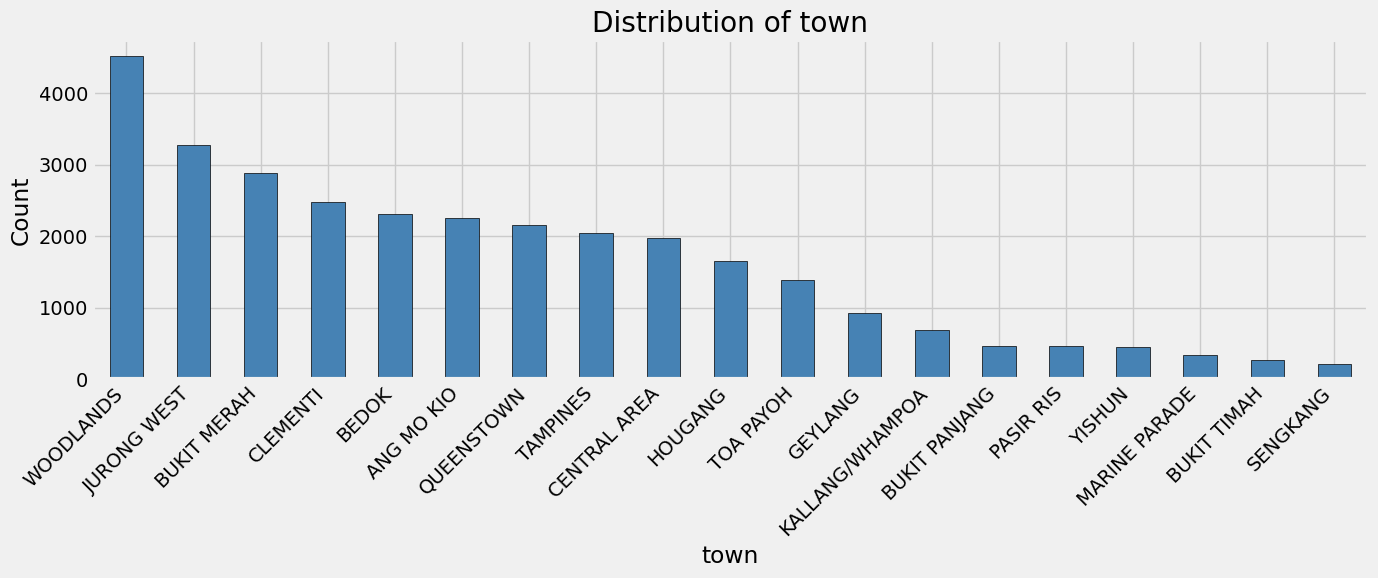

In [8]:
# Check target variable distribution
print(f"Target variable distribution ({TARGET_COLUMN}):")
print(df[TARGET_COLUMN].value_counts())

# Visualize target distribution
plt.figure(figsize=(14, 6))
df[TARGET_COLUMN].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Step 4: Exploratory Data Analysis (EDA) - Feature Distributions

For KNN classification, **correlation analysis is not as important** as it is for linear models. KNN is a distance-based algorithm that doesn't assume linear relationships between features and the target.

**What matters for KNN:**
- How well features **separate the classes** (visualized with boxplots)
- Feature **scale** (addressed with StandardScaler in Step 5)
- Feature **distribution** within each class

### 4a. Feature Distribution by Target Class (Boxplots)

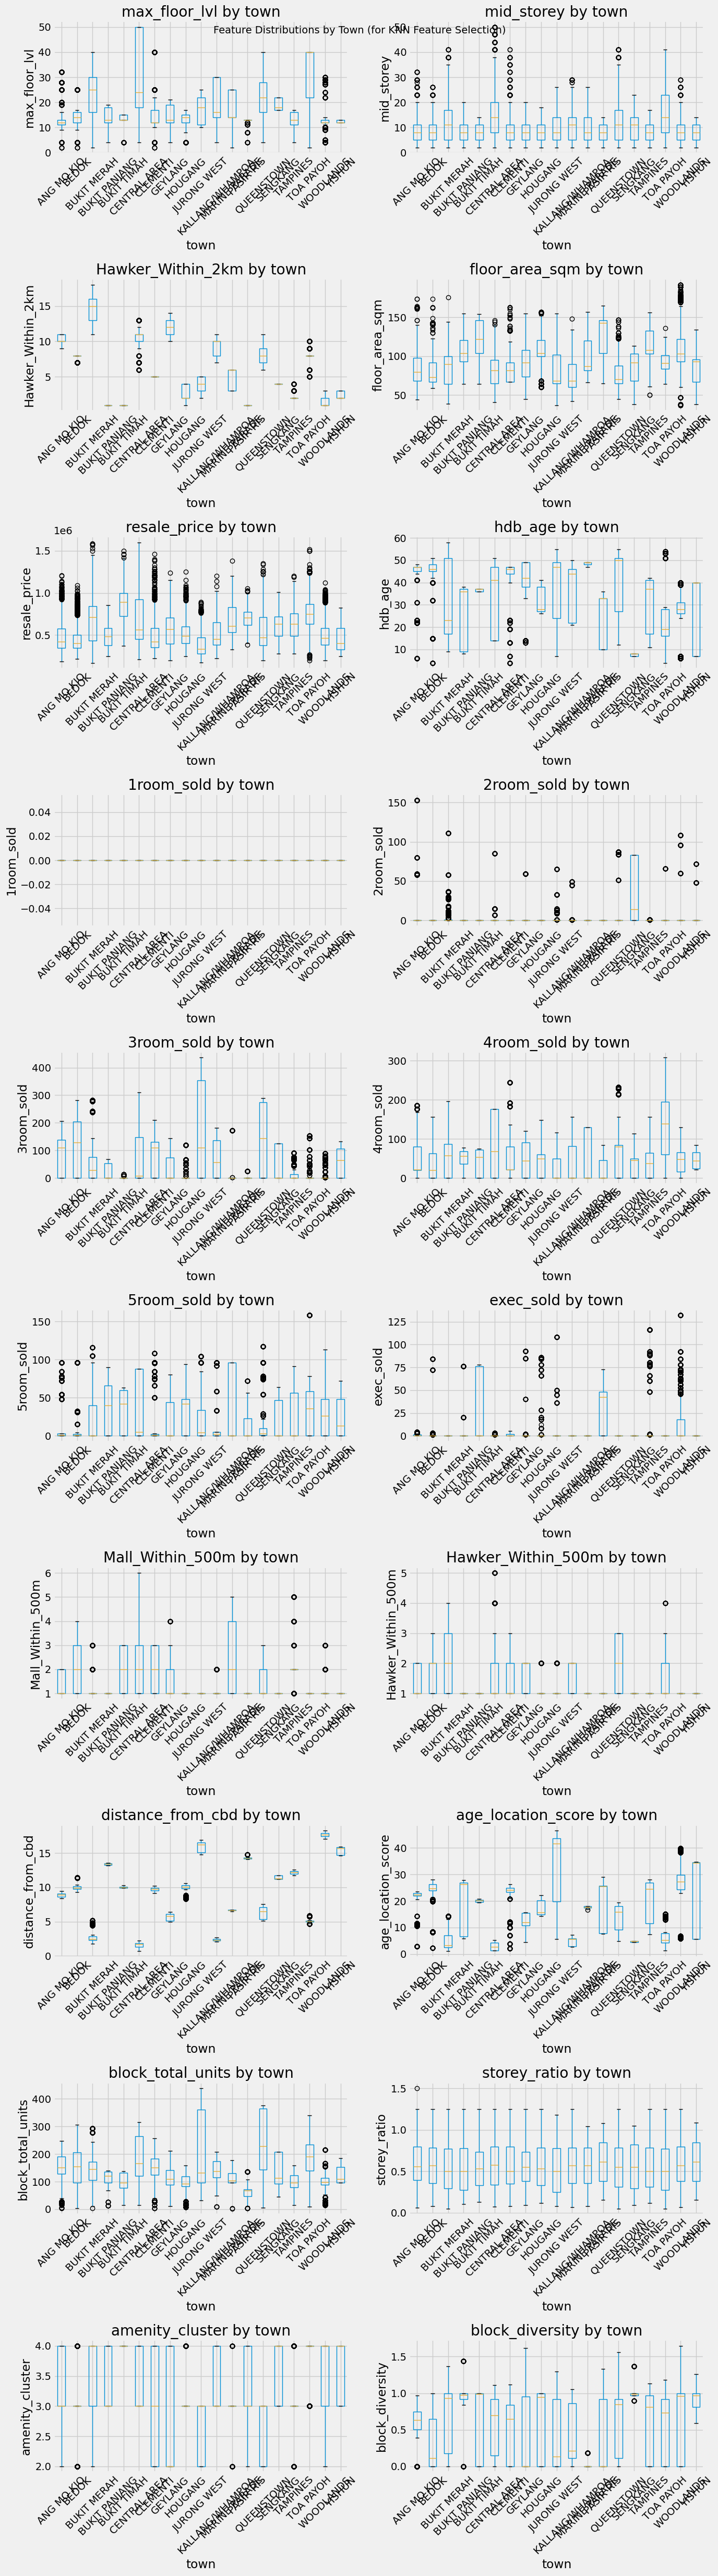

In [9]:
# ========== MODIFY THIS ==========

FEATURES_TO_PLOT = [
    'max_floor_lvl',
    'mid_storey',
    'Hawker_Within_2km',
    'floor_area_sqm',
    'resale_price',
    'hdb_age',
    '1room_sold',
    '2room_sold',
    '3room_sold',
    '4room_sold',
    '5room_sold',
    'exec_sold',
    'Mall_Within_500m',
    'Hawker_Within_500m',
    'distance_from_cbd',
    'age_location_score',
    'block_total_units',
    'storey_ratio',
    'amenity_cluster',
    'block_diversity'
]

# =================================

# Box plots for key features by target class
# This shows how well each feature separates the different classes
n_features = len(FEATURES_TO_PLOT)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES_TO_PLOT):
    if col in df.columns:
        df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[i])
        axes[i].set_title(f'{col} by {TARGET_COLUMN}')
        axes[i].set_xlabel(TARGET_COLUMN)
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots if odd number of features
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Town (for KNN Feature Selection)', fontsize=14)
plt.tight_layout()
plt.show()


**Interpreting Boxplots for KNN:**
- **Good features:** Show clear separation between classes (minimal overlap in boxes)
- **Less useful features:** Classes overlap significantly
- Features with better class separation will contribute more to accurate KNN predictions

### 4b. Class Separation Summary

In [10]:
# Calculate mean values per class to understand feature separation
class_means = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].mean()
print("Mean feature values by town:")
display(class_means.round(2))

Mean feature values by town:


,max_floor_lvl,mid_storey,Hawker_Within_2km,floor_area_sqm,resale_price,hdb_age,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,Mall_Within_500m,Hawker_Within_500m,distance_from_cbd,age_location_score,block_total_units,storey_ratio,amenity_cluster,block_diversity
town,,,,,,,,,,,,,,,,,,,,
ANG MO KIO,14.46,8.02,10.02,83.53,474546.75,42.40,0.0,5.92,84.71,43.54,14.72,0.70,1.34,1.26,8.89,20.57,149.59,0.57,3.24,0.54
BEDOK,14.13,7.66,7.85,80.82,450884.17,41.98,0.0,0.00,106.62,37.59,10.21,1.61,2.24,1.69,9.96,22.80,156.04,0.56,3.00,0.31
BUKIT MERAH,23.56,12.11,14.55,85.69,673233.11,30.58,0.0,6.05,53.13,57.81,26.36,0.00,1.15,2.03,2.74,4.73,143.34,0.53,3.36,0.72
BUKIT PANJANG,14.62,7.78,1.00,105.13,491951.59,25.52,0.0,0.00,18.59,48.80,35.91,7.25,1.00,1.00,13.39,18.62,110.56,0.54,3.46,0.91
BUKIT TIMAH,13.07,6.99,1.00,124.37,892320.04,36.58,0.0,0.00,0.49,38.21,31.10,27.80,1.97,1.00,10.04,20.09,97.61,0.55,4.00,0.60
CENTRAL AREA,29.43,16.48,10.59,82.01,686844.11,33.88,0.0,1.86,72.23,81.10,32.80,0.10,2.20,1.79,1.60,2.83,188.10,0.58,3.38,0.57
CLEMENTI,15.56,8.35,5.00,83.04,484208.75,41.57,0.0,0.00,84.35,52.22,13.02,0.83,1.87,1.56,9.74,22.16,150.42,0.55,3.05,0.53
GEYLANG,15.34,8.31,12.01,94.01,569046.32,38.29,0.0,4.06,41.94,50.67,16.52,5.68,1.49,1.58,5.60,11.60,118.88,0.55,2.77,0.41
HOUGANG,13.38,7.26,2.45,107.84,518915.72,32.09,0.0,0.00,14.43,44.96,31.01,6.54,1.00,1.06,9.93,17.32,96.94,0.55,3.08,0.63


In [11]:
# Calculate standard deviation to understand spread
class_std = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].std()
print("Standard deviation by town:")
display(class_std.round(2))

Standard deviation by town:


,max_floor_lvl,mid_storey,Hawker_Within_2km,floor_area_sqm,resale_price,hdb_age,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,Mall_Within_500m,Hawker_Within_500m,distance_from_cbd,age_location_score,block_total_units,storey_ratio,amenity_cluster,block_diversity
town,,,,,,,,,,,,,,,,,,,,
ANG MO KIO,6.27,5.41,0.69,20.37,181548.71,10.03,0.0,26.16,74.19,47.72,27.87,1.07,0.47,0.44,0.28,4.78,45.32,0.28,0.79,0.32
BEDOK,4.22,4.55,0.36,19.17,156513.20,11.36,0.0,0.00,94.09,51.00,25.99,10.20,1.18,0.67,0.33,6.11,60.50,0.29,0.43,0.34
BUKIT MERAH,9.82,8.41,1.97,23.03,251671.21,16.63,0.0,16.89,73.17,54.83,33.42,0.00,0.43,0.76,0.78,3.26,57.15,0.29,0.76,0.46
BUKIT PANJANG,3.46,4.45,0.00,21.19,133666.49,13.86,0.0,0.00,29.23,21.85,31.71,20.97,0.00,0.00,0.11,10.06,26.40,0.28,0.50,0.29
BUKIT TIMAH,2.90,3.82,0.00,21.45,218585.93,0.49,0.0,0.00,2.27,33.85,28.41,35.61,0.86,0.00,0.13,0.44,34.50,0.29,0.00,0.49
CENTRAL AREA,14.95,11.54,1.67,18.97,298074.26,15.15,0.0,10.09,91.32,75.09,39.82,0.48,1.25,1.04,0.39,1.35,76.67,0.27,0.49,0.38
CLEMENTI,7.26,6.06,0.00,17.30,187596.34,10.26,0.0,0.00,69.49,56.15,30.18,1.26,0.88,0.76,0.27,5.55,49.44,0.29,0.92,0.38
GEYLANG,4.43,4.82,1.24,25.84,189279.10,12.15,0.0,14.95,55.35,45.89,27.71,21.28,0.78,0.49,0.46,3.70,42.96,0.27,0.88,0.58
HOUGANG,2.96,4.06,1.10,22.52,158902.26,5.87,0.0,0.00,32.15,37.05,28.12,21.27,0.00,0.23,0.62,2.76,28.41,0.28,0.27,0.45


### 4c. Optional: Correlation Matrix (for Multicollinearity Check Only)

> **Note:** Correlation is not used for feature-target relationship in KNN, but can help identify **multicollinearity** (highly correlated features that may be redundant).

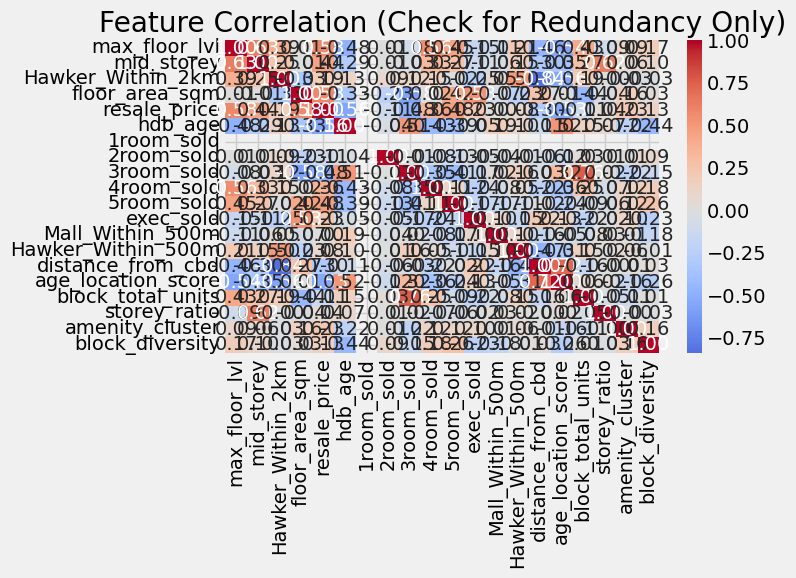


Highly correlated feature pairs (|r| > 0.8):
  Hawker_Within_2km & distance_from_cbd = -0.84


In [12]:
# Optional: Check for redundant features (multicollinearity)
numeric_cols = df[FEATURES_TO_PLOT]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Feature Correlation (Check for Redundancy Only)')
plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (consider removing one)
CORRELATION_THRESHOLD = 0.8
print(f"\nHighly correlated feature pairs (|r| > {CORRELATION_THRESHOLD}):")
found_high_corr = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > CORRELATION_THRESHOLD:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]} = {corr_matrix.iloc[i, j]:.2f}")
            found_high_corr = True
if not found_high_corr:
    print("  None found - features are not highly correlated with each other.")

---

## Step 5: Model Preprocessing

### 5a. Map Categorical Labels to Numeric Labels

In [13]:
# ========== MODIFY THIS ==========
TARGET_NUMERIC_COL = 'town_num'  # Name for the new numeric column
# =================================

# Map target to numeric values
df[TARGET_NUMERIC_COL] = df[TARGET_COLUMN].map(TARGET_MAPPING)

# Check for any unmapped values (NaN)
unmapped = df[df[TARGET_NUMERIC_COL].isna()][TARGET_COLUMN].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped values found: {unmapped}")
    print("Update TARGET_MAPPING to include these values.")
else:
    print("All target values successfully mapped!")

# Verify mapping
print("\nTarget mapping verification:")
print(df[[TARGET_COLUMN, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL))

All target values successfully mapped!

Target mapping verification:
                  town  town_num
0           ANG MO KIO         0
27               BEDOK         1
41         BUKIT MERAH         4
59       BUKIT PANJANG         5
61         BUKIT TIMAH         6
65        CENTRAL AREA         7
74            CLEMENTI         9
87             GEYLANG        10
91             HOUGANG        11
104        JURONG WEST        13
121    KALLANG/WHAMPOA        14
125      MARINE PARADE        15
132          PASIR RIS        16
134         QUEENSTOWN        18
17948         SENGKANG        20
143           TAMPINES        22
155          TOA PAYOH        23
162          WOODLANDS        24
204             YISHUN        25


### 5b. Define Feature Columns and Set X and y

In [14]:
# ========== MODIFY THIS ==========
# Keep only leakage-safe features (no target column or target-derived column in X)

if 'df' not in globals():
    raise RuntimeError("`df` is not available. Run Step 1 to Step 3.5 first.")
if TARGET_NUMERIC_COL not in df.columns:
    raise RuntimeError("`town_num` is missing. Run Step 5a first.")

# Core features (kept from current workflow)
NUMERIC_FEATURES = [
    'max_floor_lvl',
    'Hawker_Within_2km',
    'floor_area_sqm',
    'resale_price'
]

# Engineered features (created in Step 3.5)
ENGINEERED_FEATURE_CANDIDATES = [
    'age_location_score',
    'block_total_units',
    'storey_ratio',
    'amenity_cluster',
    'block_diversity'
]

ENGINEERED_FEATURES = [col for col in ENGINEERED_FEATURE_CANDIDATES if col in df.columns]
FEATURE_COLUMNS = NUMERIC_FEATURES + ENGINEERED_FEATURES
# =================================

# Verify all features exist
missing_cols = [col for col in FEATURE_COLUMNS if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing feature columns: {missing_cols}")

# Target leakage guard
forbidden_features = {TARGET_COLUMN, TARGET_NUMERIC_COL}
present_forbidden = [col for col in FEATURE_COLUMNS if col in forbidden_features]
if present_forbidden:
    raise ValueError(f"Target leakage detected. Remove target columns from features: {present_forbidden}")

print(f"All {len(FEATURE_COLUMNS)} features found in dataset")
print(f"  - Numeric features: {NUMERIC_FEATURES}")
print(f"  - Engineered features: {ENGINEERED_FEATURES}")
print("Leakage guard passed: target columns are excluded from X.")

# Create feature matrix (X) and target vector (y)
X = df[FEATURE_COLUMNS]
y = df[TARGET_NUMERIC_COL]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

All 9 features found in dataset
  - Numeric features: ['max_floor_lvl', 'Hawker_Within_2km', 'floor_area_sqm', 'resale_price']
  - Engineered features: ['age_location_score', 'block_total_units', 'storey_ratio', 'amenity_cluster', 'block_diversity']
Leakage guard passed: target columns are excluded from X.

X shape: (30785, 9)
y shape: (30785,)


In [15]:
# pd.concat([X, y], axis=1).to_csv('classification_first_permutation.csv', index=False)

### 5c. Split Data into Training and Testing Sets


In [16]:
# ========== MODIFY THIS ==========
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
 )

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Training set size: {X_train.shape[0]:,} rows")
print(f"Testing set size:  {X_test.shape[0]:,} rows")
print(f"Train class count: {y_train.nunique()} | Test class count: {y_test.nunique()}")
print("Leakage guard: train/test split is stratified and completed before any model fitting.")

Training set size: 23,088 rows
Testing set size:  7,697 rows
Train class count: 19 | Test class count: 19
Leakage guard: train/test split is stratified and completed before any model fitting.


### 5d. Feature Scaling with StandardScaler

**Why Scale?** KNN uses distance calculations, so features with larger scales can dominate the distance metric. StandardScaler normalizes features to have mean=0 and std=1.

In [17]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

print("Scaled training data statistics:")
print(X_train_scaled_df.describe().round(2))

Scaled training data statistics:
       max_floor_lvl  Hawker_Within_2km  floor_area_sqm  resale_price  \
count       23088.00           23088.00        23088.00      23088.00   
mean           -0.00               0.00            0.00         -0.00   
std             1.00               1.00            1.00          1.00   
min            -1.71              -1.23           -2.14         -1.70   
25%            -0.62              -1.00           -0.94         -0.77   
50%            -0.40              -0.31           -0.04         -0.26   
75%             0.47               0.84            0.70          0.63   
max             3.52               2.68            3.88          4.82   

       age_location_score  block_total_units  storey_ratio  amenity_cluster  \
count            23088.00           23088.00      23088.00         23088.00   
mean                -0.00               0.00         -0.00            -0.00   
std                  1.00               1.00          1.00             1

In [18]:
# ========== SMOTE ON TRAINING DATA (MANDATORY) ==========
# Apply SMOTE to TRAINING data only to avoid data leakage.
# This notebook now always uses SMOTE and no longer keeps optional KNN-era toggles.
# ========================================================

_X_train_base = X_train.copy()
_y_train_base = y_train.copy()
_X_test_base = X_test.copy()
_y_test_base = y_test.copy()

# Always start from base split
X_train = _X_train_base.copy()
y_train = _y_train_base.copy()
X_test = _X_test_base.copy()
y_test = _y_test_base.copy()

# Apply SMOTE on training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("SMOTE applied to training data only.")

# Prepare XGBoost-safe labels once (consecutive integers from 0)
xgb_label_encoder = LabelEncoder()
y_train_xgb = xgb_label_encoder.fit_transform(y_train)

missing_test_classes = set(np.unique(y_test)) - set(xgb_label_encoder.classes_)
if missing_test_classes:
    raise ValueError(f"XGBoost label encoding issue. Classes in test but not train: {sorted(missing_test_classes)}")

y_test_xgb = xgb_label_encoder.transform(y_test)
print("XGBoost label mapping prepared in preprocessing.")

# Scale AFTER final training data is set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train rows after SMOTE: {len(y_train):,} | Test rows: {len(y_test):,}")
print("Leakage guard: scaler is fit on training data only.")

SMOTE applied to training data only.
XGBoost label mapping prepared in preprocessing.
Train rows after SMOTE: 64,334 | Test rows: 7,697
Leakage guard: scaler is fit on training data only.


---



## Step 6: Tune Logistic Regression (C)



Test different `C` values and pick the one with the lowest testing error.


In [19]:
# ========== MODIFY THIS ==========
C_VALUES = [0.01, 0.1, 1, 10, 100]
CV_FOLDS = 5
# =================================

required_vars = ['X_train_scaled', 'X_test_scaled', 'y_train', 'y_test']
missing_state = [var for var in required_vars if var not in globals()]
if missing_state:
    raise RuntimeError(f"Missing required variables: {missing_state}. Run Step 5 cells first.")

lr_search = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

param_grid = {'C': C_VALUES}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    estimator=lr_search,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
 )

search_start = time.perf_counter()
search.fit(X_train_scaled, y_train)
search_runtime = time.perf_counter() - search_start

cv_results = pd.DataFrame(search.cv_results_)[['param_C', 'mean_test_score', 'std_test_score']]
cv_results = cv_results.rename(columns={'param_C': 'C', 'mean_test_score': 'cv_accuracy', 'std_test_score': 'cv_std'})
cv_results = cv_results.sort_values('cv_accuracy', ascending=False).reset_index(drop=True)

best_C = search.best_params_['C']
print(f"Best C from CV: {best_C}")
print(f"CV search runtime (sec): {search_runtime:.3f}")
display(cv_results)

Best C from CV: 100
CV search runtime (sec): 54.937


,C,cv_accuracy,cv_std
0,100.00,0.818743,0.002292
1,10.00,0.815712,0.002239
2,1.00,0.801847,0.001934
3,0.10,0.762956,0.002163
4,0.01,0.674558,0.002360


### Visualize Training vs Testing Error by C


In [20]:
print("Logistic Regression C tuning completed with train-only cross-validation.")
print(f"Best C selected: {best_C}")
print("No error plot generated by design (metrics-only workflow).")

Logistic Regression C tuning completed with train-only cross-validation.
Best C selected: 100
No error plot generated by design (metrics-only workflow).


---



## Step 7: Train Final Logistic Regression and Evaluate



Train the model using the best `C` value and evaluate performance.


In [21]:
# Train final logistic regression with CV-selected C
lr_final = LogisticRegression(
    C=best_C,
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

lr_start = time.perf_counter()
lr_final.fit(X_train_scaled, y_train)
lr_runtime = time.perf_counter() - lr_start

lr_train_acc = lr_final.score(X_train_scaled, y_train)
lr_test_acc = lr_final.score(X_test_scaled, y_test)

print("Logistic Regression (final)")
print(f"Train Accuracy: {lr_train_acc:.4f}")
print(f"Test Accuracy : {lr_test_acc:.4f}")
print(f"Runtime (sec) : {lr_runtime:.3f}")

Logistic Regression (final)
Train Accuracy: 0.8194
Test Accuracy : 0.7524
Runtime (sec) : 11.236


### Detailed Classification Report

In [22]:
# Logistic feature importance from absolute coefficients (multiclass average)
lr_importance = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': np.mean(np.abs(lr_final.coef_), axis=0)
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top Logistic Regression feature importance:")
print(lr_importance.head(10).to_string(index=False))

Top Logistic Regression feature importance:
           Feature  Importance
 Hawker_Within_2km   38.399149
age_location_score   10.627720
      resale_price    2.364870
 block_total_units    2.134648
     max_floor_lvl    1.833900
   amenity_cluster    1.553089
    floor_area_sqm    1.333400
   block_diversity    1.292211
      storey_ratio    0.245635


In [23]:
print("Confusion matrix plot removed to keep notebook focused on")
print("train accuracy, test accuracy, runtime, and feature importance.")

Confusion matrix plot removed to keep notebook focused on
train accuracy, test accuracy, runtime, and feature importance.


---

## Step 8: Define Model Evaluation Helper Functions

Create reusable functions to train each classifier and display its performance — mirroring the same pattern used for each model in Steps 9–12.


In [24]:
def extract_feature_importance(model, feature_columns):
    if hasattr(model, 'feature_importances_'):
        values = model.feature_importances_
    elif hasattr(model, 'coef_'):
        coef = model.coef_
        values = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    else:
        return pd.DataFrame(columns=['Feature', 'Importance'])

    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': values
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    return importance_df

def evaluate_classification_model(model, X_train_data, X_test_data, y_train_data, y_test_data, model_name, feature_columns):
    start = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    runtime = time.perf_counter() - start

    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    if 'CatBoost' in type(model).__name__:
        train_pred = np.array(train_pred).astype(int).ravel()
        test_pred = np.array(test_pred).astype(int).ravel()

    train_acc = accuracy_score(y_train_data, train_pred)
    test_acc = accuracy_score(y_test_data, test_pred)
    importance_df = extract_feature_importance(model, feature_columns)

    return {
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Runtime (sec)': runtime,
        'Feature Importance': importance_df,
        'fitted_model': model
    }

print("Reusable evaluation helpers defined.")

Reusable evaluation helpers defined.


In [25]:
# Prepare shared inputs used by every model evaluation cell (Steps 9–12).

# All models are evaluated on the SAME train/test split for a fair comparison.

# X_train, X_test, y_train, y_test were created in Step 5c.



# Class names — town labels in the same sorted order as the numeric encoding

class_names = [label for label, _ in sorted(TARGET_MAPPING.items(), key=lambda x: x[1])]



print(f"Shared train / test split : {len(X_train)} train | {len(X_test)} test")
print(f"Class names ({len(class_names)} towns)  : {class_names}")
print()

print("Note: Logistic Regression (Steps 6–7) uses X_train_scaled / X_test_scaled.")
print("      Tree models below use raw X_train / X_test.")


Shared train / test split : 64334 train | 7697 test
Class names (26 towns)  : ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

Note: Logistic Regression (Steps 6–7) uses X_train_scaled / X_test_scaled.
      Tree models below use raw X_train / X_test.


---

## Step 9a: Common parameters to modify


In [26]:
# MODIFY THIS CELL TO EVALUATE YOUR MODELS (Steps 9b–12)
N_ESTIMATORS = 300  # Number of trees in the forest (tune for better performance)

---

## Step 9b: Random Forest Model

An ensemble of decision trees that votes on the most likely class.  
No feature scaling required — Random Forest is scale-invariant.

In [27]:
# ========== RANDOM FOREST ==========
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1
)

rf_results = evaluate_classification_model(
    rf_model, X_train, X_test, y_train, y_test,
    'Random Forest', FEATURE_COLUMNS
)

print("Random Forest")
print(f"Train Accuracy: {rf_results['Train Accuracy']:.4f}")
print(f"Test Accuracy : {rf_results['Test Accuracy']:.4f}")
print(f"Runtime (sec) : {rf_results['Runtime (sec)']:.3f}")

Random Forest
Train Accuracy: 1.0000
Test Accuracy : 0.9995
Runtime (sec) : 7.583


In [28]:
print("Top Random Forest feature importance:")
print(rf_results['Feature Importance'].head(10).to_string(index=False))

Top Random Forest feature importance:
           Feature  Importance
age_location_score    0.294026
 Hawker_Within_2km    0.281111
     max_floor_lvl    0.118803
 block_total_units    0.075173
   block_diversity    0.067727
   amenity_cluster    0.059226
    floor_area_sqm    0.053926
      resale_price    0.047397
      storey_ratio    0.002610


---

## Step 10: LightGBM Model

Gradient boosting with fast leaf-wise tree growth.  
No feature scaling required — LightGBM is scale-invariant.


In [29]:
# ========== LIGHTGBM ==========
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE
    )
    lgbm_results = evaluate_classification_model(
        lgbm_model, X_train, X_test, y_train, y_test,
        'LightGBM', FEATURE_COLUMNS
    )
    print("LightGBM")
    print(f"Train Accuracy: {lgbm_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {lgbm_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {lgbm_results['Runtime (sec)']:.3f}")
else:
    print("LightGBM is not installed. Run: pip install lightgbm")
    lgbm_results = None

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2036
[LightGBM] [Info] Number of data points in the train set: 64334, number of used features: 9
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -2.944439


In [30]:
if lgbm_results is not None:
    print("Top LightGBM feature importance:")
    print(lgbm_results['Feature Importance'].head(10).to_string(index=False))

Top LightGBM feature importance:
           Feature  Importance
age_location_score       21540
     max_floor_lvl       16574
 Hawker_Within_2km       14842
   block_diversity       13373
    floor_area_sqm       12435
 block_total_units       12282
      resale_price       10775
      storey_ratio        3464
   amenity_cluster        3280


---

## Step 11: XGBoost Model

Gradient boosting with level-wise tree growth and built-in regularisation (L1/L2).  
No feature scaling required — XGBoost is scale-invariant.


In [31]:
# ========== XGBOOST ==========
if XGBClassifier is not None:
    required_vars = ['y_train_xgb', 'y_test_xgb', 'xgb_label_encoder']
    missing_vars = [var for var in required_vars if var not in globals()]
    if missing_vars:
        raise RuntimeError(f"Missing XGBoost label variables: {missing_vars}. Run the SMOTE preprocessing cell first.")

    xgb_model = XGBClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softmax',
        num_class=len(xgb_label_encoder.classes_),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    xgb_results = evaluate_classification_model(
        xgb_model, X_train, X_test, y_train_xgb, y_test_xgb,
        'XGBoost', FEATURE_COLUMNS
    )
    print("XGBoost")
    print(f"Train Accuracy: {xgb_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {xgb_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {xgb_results['Runtime (sec)']:.3f}")
else:
    print("XGBoost is not installed. Run: pip install xgboost")
    xgb_results = None

XGBoost
Train Accuracy: 1.0000
Test Accuracy : 0.9997
Runtime (sec) : 14.847


In [32]:
if xgb_results is not None:
    print("Top XGBoost feature importance:")
    print(xgb_results['Feature Importance'].head(10).to_string(index=False))

Top XGBoost feature importance:
           Feature  Importance
 Hawker_Within_2km    0.372863
age_location_score    0.217798
   amenity_cluster    0.160927
     max_floor_lvl    0.082664
   block_diversity    0.058263
 block_total_units    0.049417
      resale_price    0.029247
    floor_area_sqm    0.027420
      storey_ratio    0.001403


---

## Step 12: CatBoost Model

Gradient boosting with built-in handling for class imbalance.  
No feature scaling required — CatBoost is scale-invariant.


In [33]:
# ========== CATBOOST ==========
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    catboost_results = evaluate_classification_model(
        catboost_model, X_train, X_test, y_train, y_test,
        'CatBoost', FEATURE_COLUMNS
    )
    print("CatBoost")
    print(f"Train Accuracy: {catboost_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {catboost_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {catboost_results['Runtime (sec)']:.3f}")
else:
    print("CatBoost is not installed. Run: pip install catboost")
    catboost_results = None

CatBoost
Train Accuracy: 0.9968
Test Accuracy : 0.9990
Runtime (sec) : 43.667


In [34]:
if catboost_results is not None:
    print("Top CatBoost feature importance:")
    print(catboost_results['Feature Importance'].head(10).to_string(index=False))

Top CatBoost feature importance:
           Feature  Importance
 Hawker_Within_2km   36.733610
age_location_score   26.194186
     max_floor_lvl    9.072455
   amenity_cluster    8.392751
   block_diversity    7.960479
 block_total_units    5.306589
    floor_area_sqm    3.560261
      resale_price    2.697030
      storey_ratio    0.082639


In [35]:
print("CatBoost feature-importance chart removed (metrics-only workflow).")

CatBoost feature-importance chart removed (metrics-only workflow).


---

## Step 13: Model Comparison Summary

Rank all trained models side-by-side on the same train/test split.


In [36]:
all_comparison_results = [
    {
        'Model': 'Logistic Regression',
        'Train Accuracy': lr_train_acc,
        'Test Accuracy': lr_test_acc,
        'Runtime (sec)': lr_runtime,
        'Feature Importance': lr_importance
    },
    rf_results,
    lgbm_results,
    xgb_results,
    catboost_results
]

all_comparison_results = [res for res in all_comparison_results if res is not None]

comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Train Accuracy': round(r['Train Accuracy'], 4),
        'Test Accuracy': round(r['Test Accuracy'], 4),
        'Runtime (sec)': round(r['Runtime (sec)'], 3)
    }
    for r in all_comparison_results
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("Model comparison summary")
print(comparison_df.to_string(index=False))

print("\nBest model by test accuracy:")
print(comparison_df.loc[0, 'Model'])

print("\nTop 5 features per model:")
for res in all_comparison_results:
    print(f"\n{res['Model']}:")
    fi = res['Feature Importance']
    if fi.empty:
        print("No feature importance available.")
    else:
        print(fi.head(5).to_string(index=False))

Model comparison summary
              Model  Train Accuracy  Test Accuracy  Runtime (sec)
            XGBoost          1.0000         0.9997         14.847
           LightGBM          1.0000         0.9996          8.370
      Random Forest          1.0000         0.9995          7.583
           CatBoost          0.9968         0.9990         43.667
Logistic Regression          0.8194         0.7524         11.236

Best model by test accuracy:
XGBoost

Top 5 features per model:

Logistic Regression:
           Feature  Importance
 Hawker_Within_2km   38.399149
age_location_score   10.627720
      resale_price    2.364870
 block_total_units    2.134648
     max_floor_lvl    1.833900

Random Forest:
           Feature  Importance
age_location_score    0.294026
 Hawker_Within_2km    0.281111
     max_floor_lvl    0.118803
 block_total_units    0.075173
   block_diversity    0.067727

LightGBM:
           Feature  Importance
age_location_score       21540
     max_floor_lvl       16574


In [37]:
# # ========== EXPORT CLASSIFICATION MODEL AND ARTEFACTS TO WEB APP ==========
# # Run this cell after training to update app/models/ with the latest model.
# # The web app (app/app.py) reads these files at startup.
# import joblib
# import json
# from pathlib import Path

# MODEL_DIR = Path("../app/models")
# MODEL_DIR.mkdir(exist_ok=True)

# # 1. Save the best classifier (Random Forest)
# joblib.dump(rf_results["fitted_model"], MODEL_DIR / "rf_classifier.joblib")
# print("Saved: rf_classifier.joblib")

# # 2. Save the fitted scaler (used to scale features before prediction)
# joblib.dump(scaler, MODEL_DIR / "scaler_classifier.joblib")
# print("Saved: scaler_classifier.joblib")

# # 3. Save the town class labels (index maps to town name, e.g. class 0 -> class_names[0])
# with open(MODEL_DIR / "town_classes.json", "w") as f:
#     json.dump(class_names, f, indent=2)
# print(f"Saved: town_classes.json  ({len(class_names)} towns)")
# for i, town in enumerate(class_names):
#     print(f"  {i}: {town}")

# print("
# All classification artefacts exported to app/models/")


---



## Summary



| Step | Model | Type | Notes |

|------|-------|------|-------|

| Step 6–7 | Logistic Regression | Linear classifier | Tuned via `C` search; requires feature scaling |

| Step 9   | Random Forest | Ensemble | 300 trees; balanced class weights; scale-invariant |

| Step 10  | LightGBM | Gradient Boosting | Fast leaf-wise growth; scale-invariant |

| Step 11  | XGBoost | Gradient Boosting | Level-wise with regularisation; scale-invariant |

| Step 12  | CatBoost | Gradient Boosting | Handles class imbalance; scale-invariant |

| Step 13  | Comparison | — | All models ranked on the same train/test split |

| Step 14  | Gallery | — | Confusion matrix per model for visual error analysis |



**How to reuse this notebook on a new dataset:**

1. Update `TARGET_COLUMN` and `DATA_PATH` in Steps 1–2

2. Adjust `FEATURE_COLUMNS` in Step 5b (and feature engineering in Step 3.5)

3. Re-run all cells — Steps 6–14 train and compare all models automatically
